# LLM의 안을 들여다보기 전에

> 다음 노트북([`microgpt-tutorial.ipynb`](microgpt-tutorial.ipynb))을 만나기 전, 큰 그림을 먼저 잡고 갑니다.

## 🎯 이 시간에 우리가 할 일

| 단계 | 내용 |
|------|------|
| ① | 앞에서 배운 것 한 줄로 말해보기 |
| ② | 🎮 다음 단어 맞히기 게임 |
| ③ | 🗺️ 오늘의 로드맵 — 우리가 어디에 있는가 |
| ④ | 🔮 곧 만날 MicroGPT 미리보기 |
| ⑤ | 💚 오늘의 마음가짐 |

---

## 잠깐, 지금까지 우리가 한 일은?

앞 시간에 우리는 **LLM(거대 언어 모델)을 "사용"하는 사람** 입장이었어요.

- 토큰화: LLM이 글을 어떻게 *받아들이는지* 봤고
- 임베딩: LLM이 단어의 의미를 *숫자로 어떻게 표현하는지* 봤고  
- 프롬프트 엔지니어링: LLM한테 *어떻게 말해야* 좋은 답을 받는지 배웠어요.

> 💡 참고: **LLM**(Large Language Model)은 ChatGPT, Claude, Gemini 같은 \"거대 언어 모델\"을 통틀어 부르는 말이에요.  
> 이 중에서도 OpenAI가 만든 모델이 **GPT** 시리즈(GPT-4, GPT-5 등)이고, 우리가 곧 직접 만들 작은 버전이 **MicroGPT**입니다.

**지금부터는 시점이 바뀝니다.**

> 🔄 **밖에서 LLM을 쓰던 입장 → LLM 안에서 무슨 일이 일어나는지 들여다보는 입장**

마치 자동차 운전법을 배운 다음에 보닛을 열어보는 것과 같아요. 🚗 → 🔧

> 🔍 그리고 \"안을 들여다보기\" 위해, 가장 대표적인 LLM 구조인 **GPT를 작게 줄인 MicroGPT**를 직접 만들어볼 거예요.

---

## ① 앞에서 배운 것, 한 줄로 말해보기 🎤

> 💬 **활동**: 옆 사람과 한 명씩 돌아가면서 자기 말로 한 문장씩 답해봅시다. 정답은 없어요!

### Q1. 토큰(Token)이 뭐였죠?

<details>
<summary>👆 클릭해서 한 줄 정리 보기</summary>

**토큰 = AI가 글을 잘게 자른 "한 입 크기" 조각**  
예: "안녕하세요" → `안녕`, `하세요` (모델마다 자르는 방식이 다름)

</details>

### Q2. 임베딩(Embedding)이 뭐였죠?

<details>
<summary>👆 클릭해서 한 줄 정리 보기</summary>

**임베딩 = 단어/문장의 "의미"를 좌표(숫자 벡터)로 표현한 것**  
비슷한 뜻 → 가까운 좌표 / 다른 뜻 → 먼 좌표

</details>

### Q3. 프롬프트 엔지니어링은 왜 필요했죠?

<details>
<summary>👆 클릭해서 한 줄 정리 보기</summary>

**같은 모델이라도 "어떻게 묻느냐"에 따라 답의 품질이 천차만별이기 때문**  
역할·맥락·예시·형식을 잘 주면 좋은 답이 나옴

</details>

---

### 🤔 그런데… 한 가지 의문이 남지 않나요?

> 우리는 *사용법*은 배웠지만, **LLM이 답을 만들어내는 "진짜 비밀"** 은 아직 안 봤어요.  
> ChatGPT한테 질문하면 *어떻게* 그럴듯한 답이 줄줄 나올까요? 🤖💭

---

## ② 🎮 다음 단어 맞히기 게임

사실 LLM이 하는 일은 **딱 한 가지**예요. 같이 게임을 하면서 알아봅시다.

### 🎲 라운드 1: 쉬운 문장

다음 빈칸에 들어갈 단어를 **5초 안에** 떠올려보세요.

> *"옛날 옛적에 한 ______ 살았어요."*

**예상 답들** :
- 공주가 (👸)
- 나무꾼이 (🪓)
- 할아버지가 (👴)
- 용이 (🐉)
- 외계인이 (👽 거의 안 나옴)

🤔 **왜 "공주"는 자주 떠오르고 "외계인"은 안 떠오를까요?**  
→ 우리가 옛날이야기를 많이 들어봤기 때문! **머릿속에 패턴이 학습되어 있는 거예요.**

---

### 🎲 라운드 2: 일상 문장

> *"나는 오늘 학교에서 ______ 배웠다."*

어떤 단어가 떠오르나요? 옆 사람과 비교해보세요.

→ 사람마다 답이 조금씩 다르지만, **"수학", "영어", "AI"** 같은 단어들이 자주 나오죠?  
→ "피자를", "우주선을" 같은 단어는 거의 안 나오고요.

**즉, 머릿속에서 단어마다 "가능성"이 다르게 매겨져요.** 📊

---

### 🎲 라운드 3 (반전): 맥락 없는 문장

> *"asdfgh ______"*

🤷 **막막하죠?** 맥락이 없으면 사람도, AI도 못 맞혀요.

---

### 💡 결론: LLM이 하는 일 = 정확히 이거예요!

<div style="background-color:#3a3a3a; color:#FFEB3B; padding:28px; border:2px solid #5a5a5a; border-left:8px solid #FF6F00; border-radius:8px; font-size:1.25em; font-weight:500;">

🌟 <span style="color:#FFFFFF;">**모든 LLM(ChatGPT, Claude, Gemini…)의 핵심 비밀**</span>:

<div style="background-color:#FF6F00; color:#FFFFFF; padding:16px; margin:14px 0; border-radius:6px; font-size:1.15em; font-weight:bold; text-align:center;">
"앞에 나온 글을 보고, 다음에 올 토큰의 확률을 계산한다."
</div>

<span style="color:#FFFFFF;">그게 전부입니다. 단, 우리는 머릿속에서 5~10개 후보를 떠올리지만,</span>  
<span style="color:#FFEB3B; font-weight:bold;">LLM은 수만 개 토큰 전체에 대해 확률을 매겨요.</span> <span style="color:#FFFFFF;">그리고 그 중 하나를 골라서 출력합니다.</span>

</div>

---

### 🤔 잠깐, 사람과 LLM은 *어떻게* 다른가요?

같은 빈칸을 채워도 사람과 LLM이 일하는 방식은 꽤 달라요.

| | 사람 🧠 | LLM 🤖 |
|---|---|---|
| **후보 범위** | 머릿속에 *떠오른* 5~10개만 | 어휘집 *전체* (수만~10만 개) |
| **걸러내기** | 무의식적으로 "말 안 되는 단어"는 *떠올리지조차 않음* | 모든 토큰에 점수를 매김. 안 어울리는 건 *낮은 점수*로 처리 |
| **확률 합** | 떠오른 것끼리 상대적 느낌 | 전체 합 = 정확히 **1.000** |

> 🧠 사람: "옛날 옛적에 한 ___" 에서 *외계인*은 단어를 알면서도 **떠올리지조차 않아요.**  
> 🤖 LLM: *외계인*도 후보에 있지만, 학습된 패턴으로 **확률을 0.00001로 매겨서** 사실상 안 뽑히게 함.

💡 **결과는 비슷하지만 방식이 달라요.** 사람은 *영리한 필터*로, LLM은 *전수 점수 계산*으로 같은 효과를 냅니다. 이게 LLM이 가끔 "전혀 예상 못한 단어"를 뱉을 때도 있는 이유예요. (필터가 학습으로 만들어진 것이라 완벽하진 않음 → 이게 바로 *환각(hallucination)*과도 연결됩니다.)

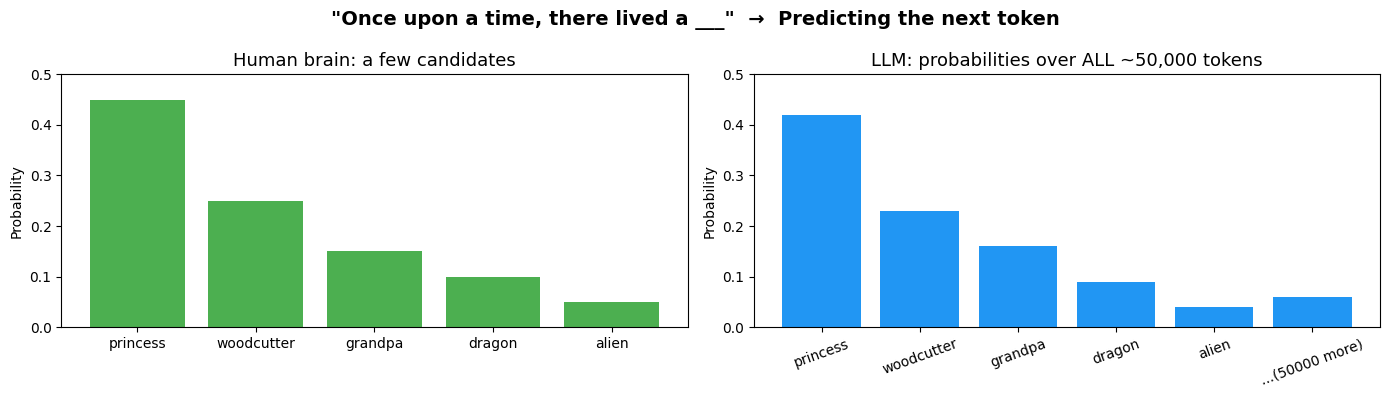


💡 사람이든 LLM이든 "다음에 올 단어의 확률 분포"를 만든다는 점에서 같습니다.
   다른 점은: LLM은 그걸 "수만 개 토큰 전체"에 대해, "수십억 개 문장에서 학습한" 패턴으로 합니다.


In [2]:
# 🎬 데모: "LLM이 하는 일"을 그림으로 보기
# (코드는 안 봐도 됩니다. 결과 그래프만 보세요!)

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'DejaVu Sans'

# 사람이 "옛날 옛적에 한 ___" 다음에 떠올릴 법한 단어 분포 (가짜 데이터)
words = ['princess', 'woodcutter', 'grandpa', 'dragon', 'alien']
human_probs = [0.45, 0.25, 0.15, 0.10, 0.05]

# LLM이 실제로 계산하는 모습 (수만 개 토큰 중 일부만 표시)
gpt_words = ['princess', 'woodcutter', 'grandpa', 'dragon', 'alien', '...(50000 more)']
gpt_probs = [0.42, 0.23, 0.16, 0.09, 0.04, 0.06]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.bar(words, human_probs, color='#4CAF50')
ax1.set_title('Human brain: a few candidates', fontsize=13)
ax1.set_ylabel('Probability')
ax1.set_ylim(0, 0.5)

ax2.bar(gpt_words, gpt_probs, color='#2196F3')
ax2.set_title('LLM: probabilities over ALL ~50,000 tokens', fontsize=13)
ax2.set_ylabel('Probability')
ax2.set_ylim(0, 0.5)
ax2.tick_params(axis='x', rotation=20)

plt.suptitle('"Once upon a time, there lived a ___"  →  Predicting the next token', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 사람이든 LLM이든 "다음에 올 단어의 확률 분포"를 만든다는 점에서 같습니다.')
print('   다른 점은: LLM은 그걸 "수만 개 토큰 전체"에 대해, "수십억 개 문장에서 학습한" 패턴으로 합니다.')


---

## ③ 🗺️ 오늘의 로드맵 — 우리는 어디에 있는가?

지금까지 배운 것과 앞으로 배울 것을 한 장으로 정리해봅시다.

```
     [입력 글]
         ↓
   ┌──────────────┐
   │  토큰화 ✅   │           ← 1·2번째 노트북에서 배움
   └──────────────┘
         ↓
   ┌──────────────┐
   │  임베딩 ✅   │           ← 3번째 노트북에서 배움
   └──────────────┘
         ↓
   ╔══════════════════════╗
   ║  ❓ 블랙박스 ❓      ║   ← 👀 오늘 들여다볼 부분!
   ║  (트랜스포머 내부)     ║
   ╚══════════════════════╝
         ↓
   ┌──────────────────┐
   │ 다음 토큰 확률     │      ← 게임에서 본 그것!
   └──────────────────┘
         ↓
   ┌──────────────┐
   │   샘플링      │          ← 확률에서 한 토큰 "뽑기"
   └──────────────┘
         ↓
     [생성된 글]
```

### 🎯 정리하면

| 이미 배운 것 ✅ | 오늘 들여다볼 것 👀 |
|----------------|---------------------|
| 글 → 토큰      | 토큰 → 다음 토큰 확률 |
| 토큰 → 벡터    | (그 안에서 일어나는 일) |
| 잘 사용하는 법 | **만들어지는 원리**   |

> 다음 노트북에서 이 "블랙박스"를 직접 만들어 돌려볼 거예요. 🛠️

---

## ④ 🔮 곧 만날 MicroGPT 미리보기

우리가 만들 모델 이름은 **MicroGPT**예요. "아주 작은 GPT"라는 뜻이죠.

### 📚 MicroGPT가 학습할 데이터

사람 이름 약 32,000개입니다. (`session-04/input.txt`)

In [3]:
# 데이터 살짝 들여다보기
with open('input.txt', 'r') as f:
    names = f.read().splitlines()

print(f'📊 총 이름 개수: {len(names):,}개')
print(f'\n👀 처음 15개:')
for n in names[:15]:
    print(f'   - {n}')
print(f'\n👀 무작위 5개:')
import random
random.seed(42)
for n in random.sample(names, 5):
    print(f'   - {n}')

📊 총 이름 개수: 32,033개

👀 처음 15개:
   - emma
   - olivia
   - ava
   - isabella
   - sophia
   - charlotte
   - mia
   - amelia
   - harper
   - evelyn
   - abigail
   - emily
   - elizabeth
   - mila
   - ella

👀 무작위 5개:
   - yovani
   - zaylynn
   - opal
   - theon
   - sira


### 🎯 MicroGPT가 풀 문제

> **"이런 이름들의 패턴을 학습해서, 이 데이터에 *없는* 새로운 이름을 만들어내라!"**

예를 들어 학습 후 모델은 이런 걸 만들 수 있어요:

- 🟢 `Marina` — 그럴듯한 새 이름!  
- 🟢 `Theodora` — 멋진 이름!  
- 🟡 `Jenva` — 약간 어색하지만 이름 같긴 함  
- 🔴 `xqwzpm` — 학습 초기엔 이런 의미 없는 글자

### 🎲 미리 예측 게임!

> 💬 **여러분이 생각하기에 MicroGPT가 어떤 새 이름을 만들어낼 것 같나요?**  
> 종이에 한 명당 1~2개씩 적어두세요. **노트북 끝에서 실제 결과와 비교해봅시다!** 📝

---

### 🌍 그런데 잠깐, 이게 우리가 쓰는 LLM이랑 무슨 상관?

사실 **여러분이 평소에 쓰는 대형 LLM도 똑같은 원리예요.** 다만 규모가 다를 뿐이죠:

| | MicroGPT (오늘) | 대형 LLM (실제 서비스) |
|---|---|---|
| 학습 데이터 | 사람 이름 3만 개 | 책·웹·코드·위키 등 **수조 토큰** |
| 만드는 것 | 새 이름 | 글·코드·번역·요약·추론 등 다양 |
| 파라미터 | 수만 개 | **수천억 ~ 수조 개 규모** |
| 학습 시간 | 1분 | 수주 ~ 수개월 |
| 학습 비용 | 거의 $0 | **약 1천억 원대 이상** |

> 즉, **MicroGPT를 이해하면 대형 LLM의 원리도 이해한 거예요.** 💡

---

## ⑤ 💚 오늘의 마음가짐

다음 노트북은 길고, 코드도 많고, 어려워 보일 수 있어요. 그래서 미리 마음가짐을 정리하고 갈게요.

<div style="background-color:#3a3a3a; color:#FFFFFF; padding:28px; border:2px solid #5a5a5a; border-left:8px solid #FF6F00; border-radius:8px; font-size:1.15em; font-weight:500;">

<span style="color:#A5D6A7;">⭕ **이것만 챙기면 OK**</span>
- "아, 이런 부품들이 모여서 GPT가 되는구나" 느낌 잡기
- 코드는 ▶️ 실행 버튼만 눌러도 충분
- <span style="color:#FFEB3B; font-weight:bold;">마지막에 ✨새 이름이 만들어지는 순간✨ 같이 보기</span>

<span style="color:#FF8A80;">❌ **하지 않아도 되는 것**</span>
- 코드 한 줄 한 줄 다 이해하기
- 수식을 종이에 옮겨 적기
- 모르는 함수 이름 외우기
- 오토그래드, 어텐션 공식 암기하기

</div>

### 🎬 다음 노트북 "4가지 관전 포인트" 미리 알려드림

| 장면 | 어디서? | 무엇을 보면 됨? |
|------|---------|---------------|
| 🎬 ① 글자가 숫자가 된다 | 2단계 | `'a'→0, 'b'→1` 매핑 확인 |
| 🎬 ② 모델은 부품들의 조합이다 | 5단계 | 다이어그램만 보기. 복잡해 보여도 OK |
| 🎬 ③ 학습하면서 점점 똑똑해진다 | 6단계 | loss 그래프가 *내려가는 것* |
| 🎬 ④ 진짜로 새 이름을 만든다 ✨ | 7단계 | **오늘의 하이라이트** |

---

## 🚀 자, 이제 [`microgpt-tutorial.ipynb`](microgpt-tutorial.ipynb)를 열어봅시다!

준비되셨나요? GPT의 "속"을 들여다보러 갑니다. 🔧🤖